In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [59]:
df=pd.read_csv("height-weight.csv")

In [60]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


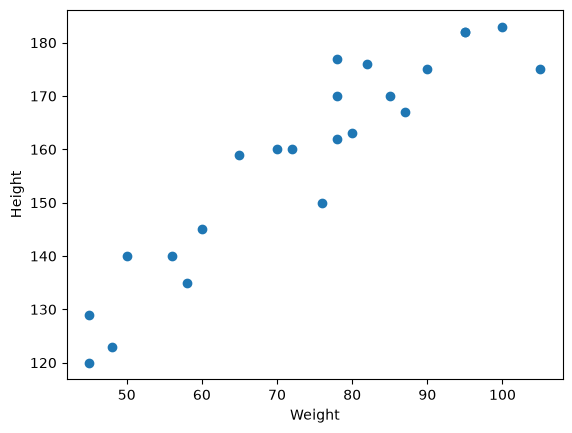

In [61]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [62]:
# divide into dependent and independent variable.
x=df[['Weight']]
y=df[['Height']]

In [63]:

from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.20,random_state=42)

In [64]:
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((18, 1), (5, 1), (18, 1), (5, 1))

In [65]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest) # we used transform as to use mean and sd of train data for test to transform it. and model dont come to know anything about test

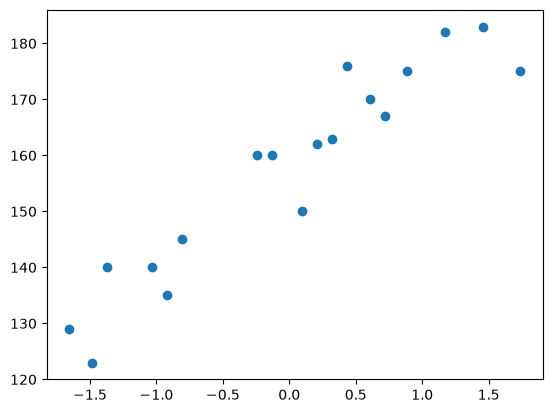

In [66]:
plt.scatter(xtrain,ytrain)

In [67]:
# applying ml model linear regression
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(xtrain,ytrain) # train the model with the training data.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print("coefficent or slop of weight(independent feature) is",reg.coef_) # we only get one coefficent as we have only 1 independent feature. it is our 01.
print("intercept:",reg.intercept_) #it is our 0o thetanot

coefficent or slop of weight(independent feature) is [[17.03440872]]
intercept: [157.5]


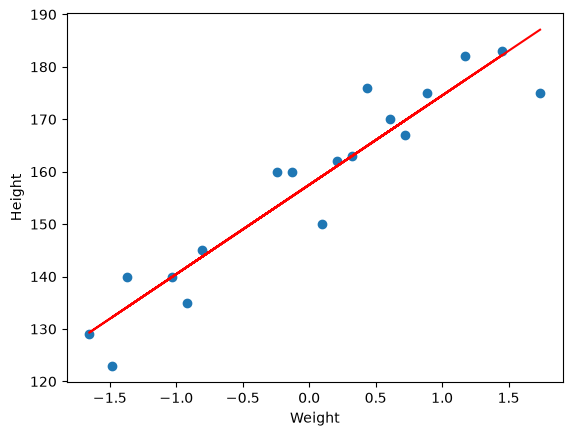

In [70]:
plt.scatter(xtrain,ytrain)
plt.plot(xtrain,reg.predict(xtrain),'r')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

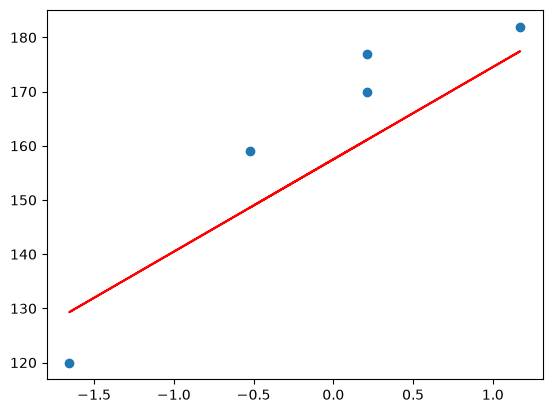

In [72]:
ytest_pred=reg.predict(xtest)
plt.scatter(xtest,ytest)
plt.plot(xtest,ytest_pred,'r')
plt.show()

## Performance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square
**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [73]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mae=mean_absolute_error(ytest,ytest_pred)
mse=mean_squared_error(ytest,ytest_pred)
rmse=np.sqrt(mse)
score=r2_score(ytest,ytest_pred)
print("mean absolute error:",mae)
print("mean squared error: ",mse)
print("root mean squared error: ",rmse)
print("r2_score:",score)
adj=1 - (1-score)*(len(ytest)-1)/(len(ytest)-xtest.shape[1]-1)
print("adjusted r2_score:",adj)


mean absolute error: 9.822657814519232
mean squared error:  109.77592599051664
root mean squared error:  10.477400726827081
r2_score: 0.776986986042344
adjusted r2_score: 0.7026493147231252


In [77]:
# new data check 
scaled_weight=scaler.transform([[80]]) #80 kg weight
scaled_weight

d:\Coding\VS CODE\vs code programs\python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [ ]:
print(reg.predict([scaled_weight[0]])) #the value came is the predicted height for scaled weight 80kg

[[163.01076266]]


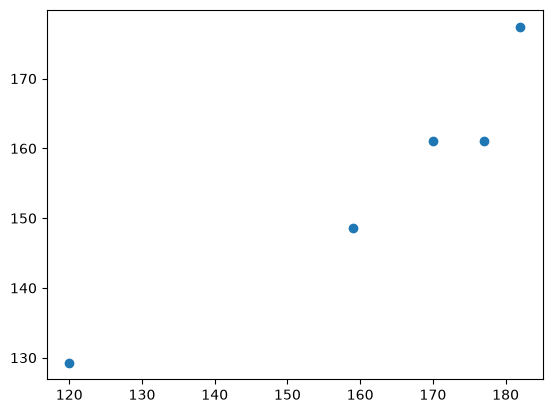

In [ ]:
#now we do assumptions if our model is correct.
# we do this by plotting a scatter plot of test data and predicted data for that test.
#if scatters are linear means the model is trained well.
plt.scatter(ytest,ytest_pred) #model is trained well.

C:\Users\NINJA-C7\AppData\Local\Temp\ipykernel_4252\3296189654.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: ylabel='Density'>

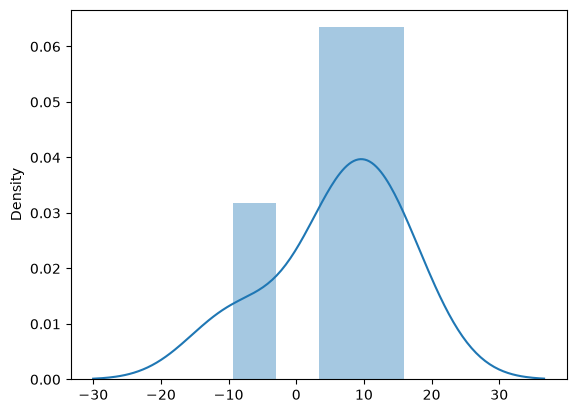

In [ ]:
# we calculate the residuals. 
residuals= ytest-ytest_pred
#also an assumption of if the model works correctly or trained well.
sns.distplot(residuals,kde=True)
# if graph showing normal distribution it means the model is working well and predicts the values correctly.


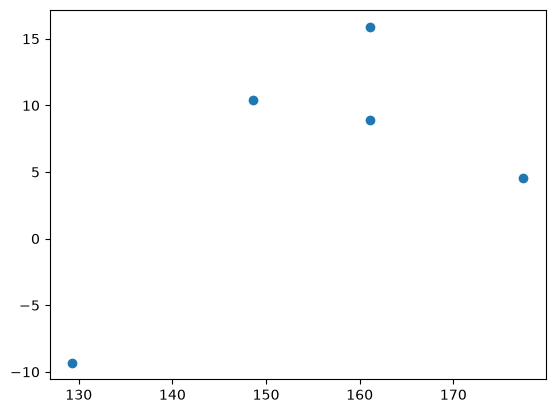

In [88]:
#also an assumption
## Scatter plot with respect to prediction and residuals
## uniform distribution means also the models is working well. pionts if scatter here and there.
plt.scatter(ytest_pred,residuals)